In [154]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
os.chdir("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/")
sys.path.insert(0, "scripts/analysis")

from helpers import (
    FEATURE_NAMES, RENAME, RENAME_INV, ZHOU_SCORES, NEW_FEATURES,
    load_roc_data, load_probs, bootstrap_auc_ci, sens_at_spec,
    build_auc_table, build_sensitivity_table,
)

# Visualization constants — notebook only (depend on seaborn)
_pal = sns.color_palette("tab20", len(FEATURE_NAMES))
FEATURE_COLORS = {f: _pal[i] for i, f in enumerate(FEATURE_NAMES)}
for _f in FEATURE_NAMES:
    FEATURE_COLORS[RENAME.get(_f, _f)] = FEATURE_COLORS[_f]

def _fcolor(name):
    return FEATURE_COLORS.get(name, FEATURE_COLORS.get(RENAME_INV.get(name, name), '#888888'))

def _oldnew_color(name):
    return '#d62728' if name in NEW_FEATURES else '#1f77b4'


## Hyperparameter Tuning

In [155]:
ht_dir = "data/model_results/hyperparam_tuning/"

rbf_mapq0 = pd.read_csv(ht_dir + "rbf_mapq0_1x10.csv")
rbf_mapq15 = pd.read_csv(ht_dir + "rbf_mapq15_1x10.csv")
rbf_mapq30 = pd.read_csv(ht_dir + "rbf_mapq30_1x10.csv")
rbf_mapq45 = pd.read_csv(ht_dir + "rbf_mapq45_1x10.csv")
linear_nopca = pd.read_csv(ht_dir + "linear_nopca_mapq30_1x10.csv")
linear_pca50 = pd.read_csv(ht_dir + "linear_pca50_mapq30_1x10.csv")
linear_pca100 = pd.read_csv(ht_dir + "linear_pca100_mapq30_1x10.csv")
linear_pca150 = pd.read_csv(ht_dir + "linear_pca150_mapq30_1x10.csv")
linear_pca200 = pd.read_csv(ht_dir + "linear_pca200_mapq30_1x10.csv")
linear_pca150_gc_1x10 = pd.read_csv(ht_dir + "linear_pca150_gc_mapq30_1x10.csv")
linear_pca150_10x10 = pd.read_csv(ht_dir + "linear_pca150_mapq30_10x10.csv")
linear_pca150_gc_10x10 = pd.read_csv(ht_dir + "linear_pca150_gc_mapq30_10x10.csv")

zhou_ref = pd.DataFrame(list(ZHOU_SCORES.items()), columns=['feature', 'zhou'])

def _merge_configs(configs):
    base = pd.DataFrame(FEATURE_NAMES, columns=['feature'])
    for col, df in configs.items():
        base = base.merge(df[['feature', 'auc']].rename(columns={'auc': col}), on='feature', how='left')
    return base.merge(zhou_ref, on='feature', how='left')

mapq_auc     = _merge_configs({'mapq0': rbf_mapq0, 'mapq15': rbf_mapq15, 'mapq30': rbf_mapq30, 'mapq45': rbf_mapq45})
kernel_auc   = _merge_configs({'rbf': rbf_mapq30, 'linear': linear_nopca})
pca_auc      = _merge_configs({'pca50': linear_pca50, 'pca100': linear_pca100, 'pca150': linear_pca150, 'pca200': linear_pca200, 'no_pca': linear_nopca})
gc_1x10_auc  = _merge_configs({'gc_false': linear_pca150, 'gc_true': linear_pca150_gc_1x10})
gc_10x10_auc = _merge_configs({'gc_false': linear_pca150_10x10, 'gc_true': linear_pca150_gc_10x10})


/tmp/ipykernel_721535/132821424.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


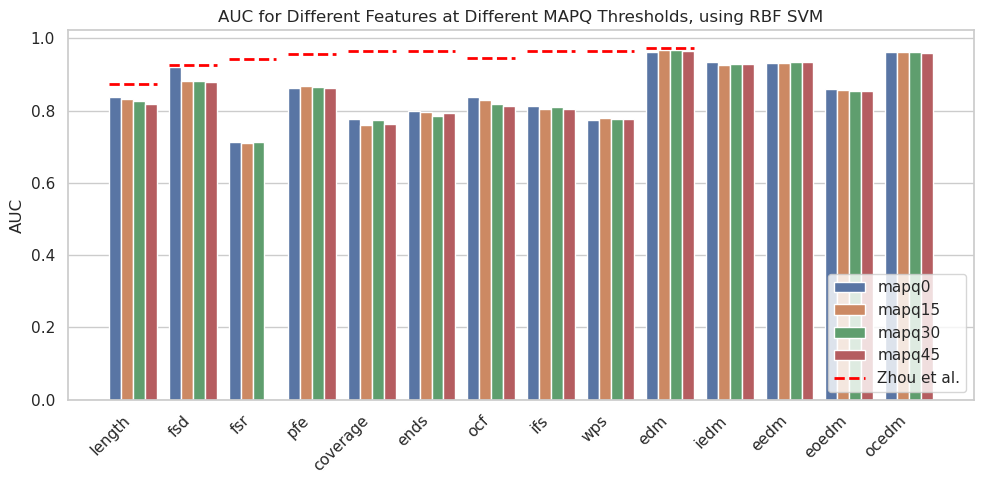

/tmp/ipykernel_721535/132821424.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


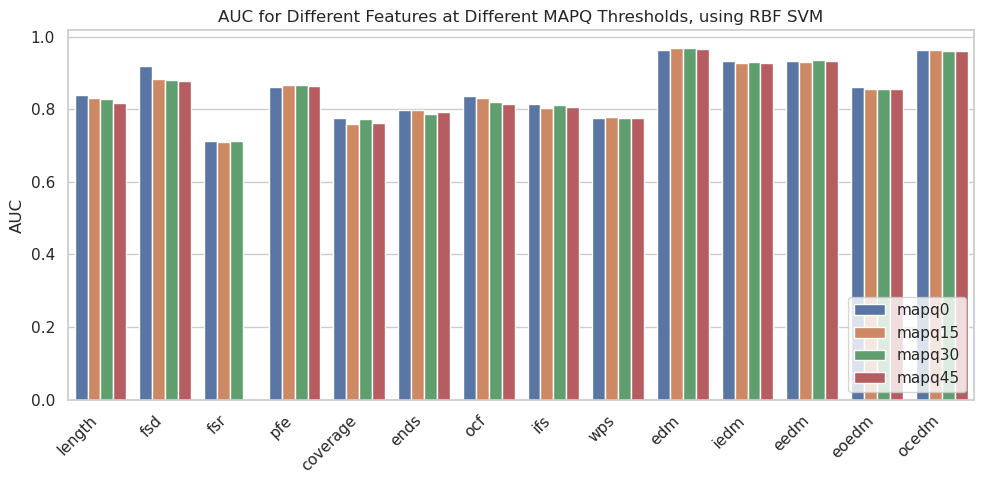

In [156]:
auc_df_melted = mapq_auc.melt(id_vars='feature', value_vars=['mapq0', 'mapq15', 'mapq30', 'mapq45'], var_name='mapq', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq', ax=ax)
for i, zhou_val in enumerate(mapq_auc['zhou']):
    ax.hlines(zhou_val, i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC for Different Features at Different MAPQ Thresholds, using RBF SVM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/01_mapq.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC for Different Features at Different MAPQ Thresholds, using RBF SVM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/01_mapq_nozh.png")
plt.show()


/tmp/ipykernel_721535/1895949437.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


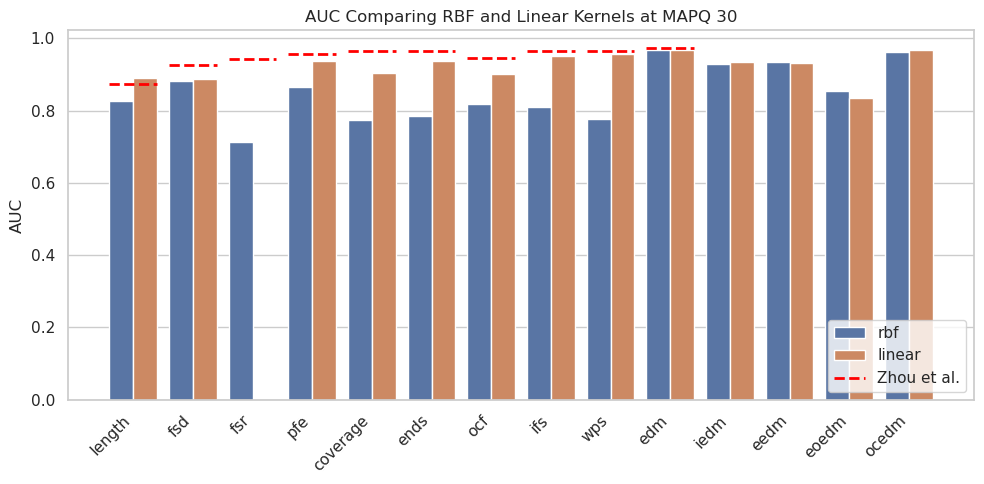

/tmp/ipykernel_721535/1895949437.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


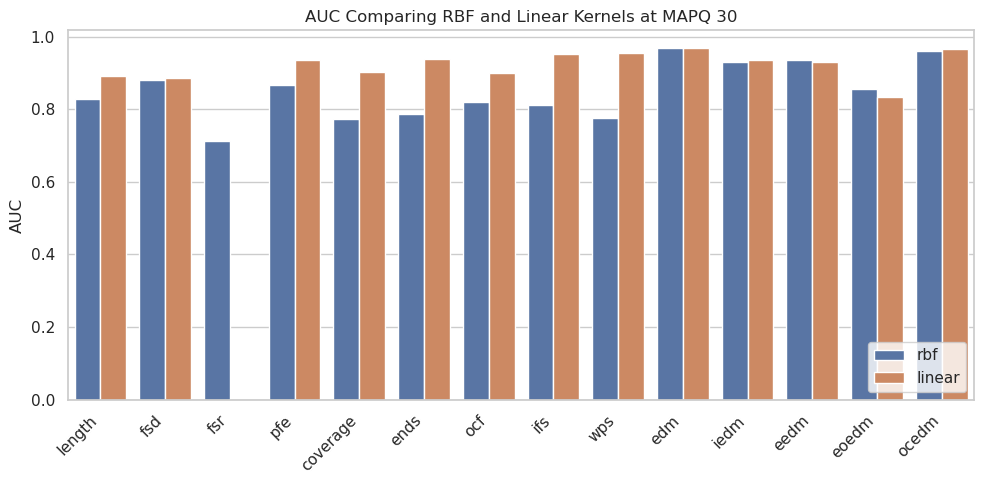

In [157]:
auc_df_melted = kernel_auc.melt(id_vars='feature', value_vars=['rbf', 'linear'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, zhou_val in enumerate(kernel_auc['zhou']):
    ax.hlines(zhou_val, i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparing RBF and Linear Kernels at MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/02_kernel.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparing RBF and Linear Kernels at MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/02_kernel_nozh.png")
plt.show()


## PCA

/tmp/ipykernel_721535/3875084867.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


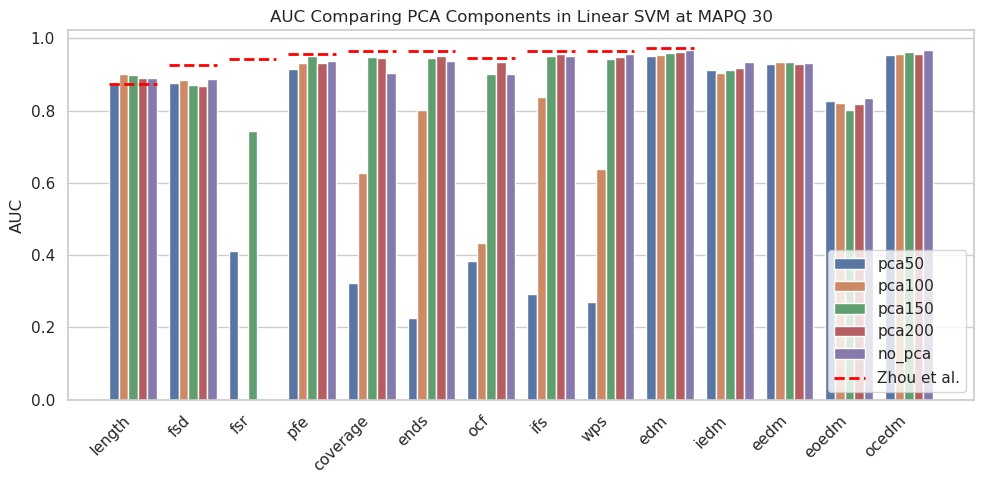

/tmp/ipykernel_721535/3875084867.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


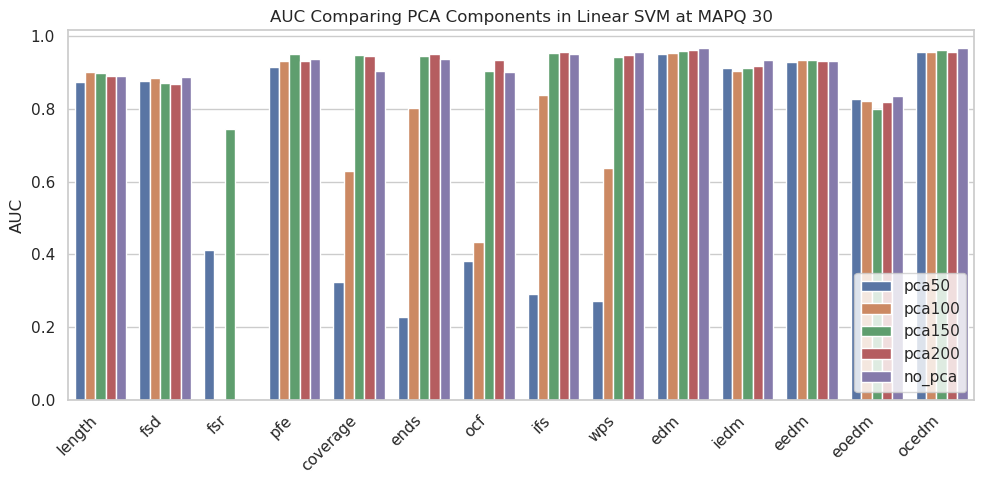

In [158]:
auc_df_melted = pca_auc.melt(id_vars='feature', value_vars=['pca50', 'pca100', 'pca150', 'pca200', 'no_pca'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, zhou_val in enumerate(pca_auc['zhou']):
    ax.hlines(zhou_val, i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparing PCA Components in Linear SVM at MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/03_pca.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparing PCA Components in Linear SVM at MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/03_pca_nozh.png")
plt.show()


## GC Correction

In [159]:
os.makedirs("scripts/analysis/tables", exist_ok=True)
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true', 'zhou']].round(4).set_index('feature')
table_zhou.to_csv("scripts/analysis/tables/04_gc_1x10.csv")
display(table_zhou)

table = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true']].round(4).set_index('feature')
table.to_csv("scripts/analysis/tables/04_gc_1x10_nozh.csv")
display(table)


,gc_false,gc_true,zhou
feature,,,
pfe,0.9507,0.9502,0.9579
coverage,0.9476,0.9160,0.9638
ends,0.9465,0.9390,0.9639
ocf,0.9028,0.9143,0.9467
ifs,0.9526,0.9404,0.9653
wps,0.9423,0.9555,0.9658


,gc_false,gc_true
feature,,
pfe,0.9507,0.9502
coverage,0.9476,0.9160
ends,0.9465,0.9390
ocf,0.9028,0.9143
ifs,0.9526,0.9404
wps,0.9423,0.9555


/tmp/ipykernel_721535/985443892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


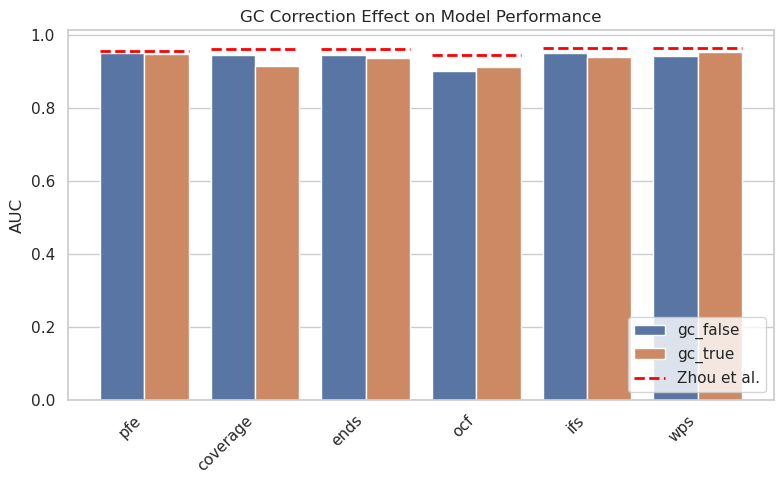

/tmp/ipykernel_721535/985443892.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


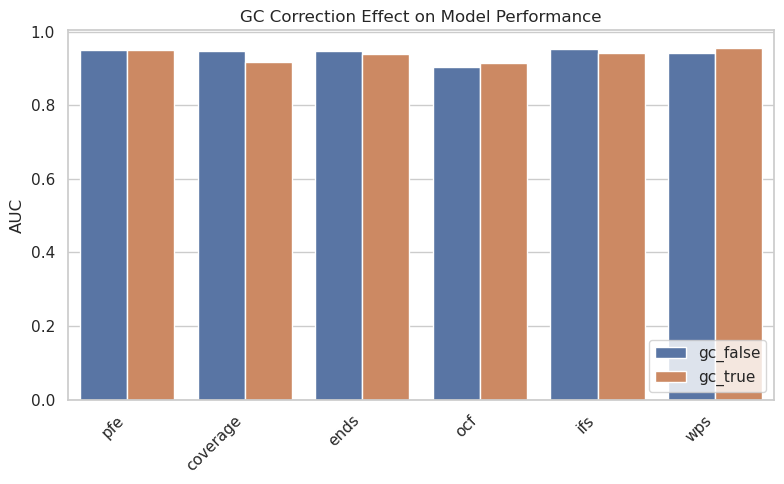

In [160]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']
auc_df_melted = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].melt(
    id_vars='feature', value_vars=['gc_false', 'gc_true'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(8, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, (_, row) in enumerate(gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect on Model Performance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/04_gc_correction.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect on Model Performance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/04_gc_correction_nozh.png")
plt.show()


In [161]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].set_index('feature')[['gc_true', 'zhou']].round(4).rename(
    columns={'gc_true': 'linear_pca150_gc_1x10', 'zhou': 'zhou_et_al'})
table_zhou.to_csv("scripts/analysis/tables/04_gc_1x10_summary.csv")
display(table_zhou)

table = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].set_index('feature')[['gc_true']].round(4).rename(
    columns={'gc_true': 'linear_pca150_gc_1x10'})
table.to_csv("scripts/analysis/tables/04_gc_1x10_summary_nozh.csv")
display(table)


,linear_pca150_gc_1x10,zhou_et_al
feature,,
pfe,0.9502,0.9579
coverage,0.9160,0.9638
ends,0.9390,0.9639
ocf,0.9143,0.9467
ifs,0.9404,0.9653
wps,0.9555,0.9658


,linear_pca150_gc_1x10
feature,
pfe,0.9502
coverage,0.9160
ends,0.9390
ocf,0.9143
ifs,0.9404
wps,0.9555


In [162]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true', 'zhou']].round(4).set_index('feature')
table_zhou.to_csv("scripts/analysis/tables/05_gc_10x10.csv")
display(table_zhou)

table = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true']].round(4).set_index('feature')
table.to_csv("scripts/analysis/tables/05_gc_10x10_nozh.csv")
display(table)


,gc_false,gc_true,zhou
feature,,,
pfe,0.9427,0.9540,0.9579
coverage,0.9566,0.9506,0.9638
ends,0.9606,0.9577,0.9639
ocf,0.9345,0.9156,0.9467
ifs,0.9610,0.9604,0.9653
wps,0.9517,0.9576,0.9658


,gc_false,gc_true
feature,,
pfe,0.9427,0.9540
coverage,0.9566,0.9506
ends,0.9606,0.9577
ocf,0.9345,0.9156
ifs,0.9610,0.9604
wps,0.9517,0.9576


/tmp/ipykernel_721535/819184665.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


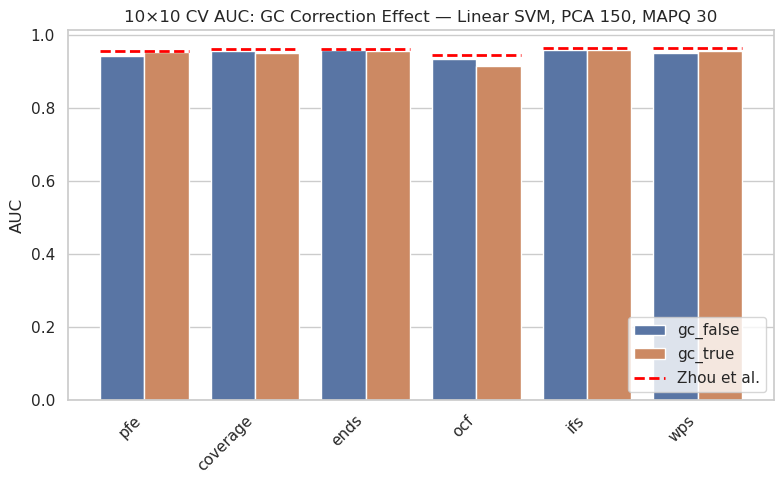

/tmp/ipykernel_721535/819184665.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


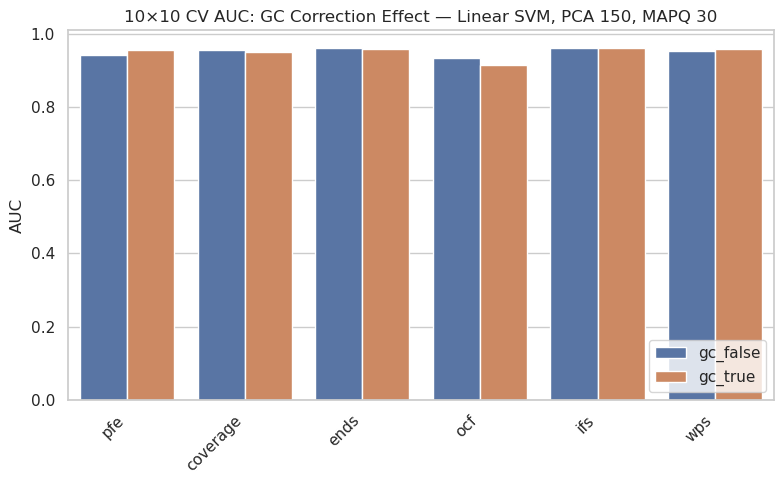

In [163]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']
auc_df_melted = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)].melt(
    id_vars='feature', value_vars=['gc_false', 'gc_true'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(8, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, (_, row) in enumerate(gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)].iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('10×10 CV AUC: GC Correction Effect — Linear SVM, PCA 150, MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/05_gc_cv10.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('10×10 CV AUC: GC Correction Effect — Linear SVM, PCA 150, MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/05_gc_cv10_nozh.png")
plt.show()


## TODO

- ROC curves — full curves for CV and external test sets (best config), no CI
- Score distributions — violin/box plots of predicted probability, cancer vs healthy, per feature
- Feature correlation heatmap — correlation of predicted probabilities across features (motivates ensemble)
- Stage-stratified AUC — Cristiano stage I/II/III/IV; use stage info from manifest
- Cross-dataset heatmap — feature × dataset AUC matrix (Cristiano/CRC train × LY/GeoScan test), once external validation complete

In [164]:
# ══════════════════════════════════════════════════════════════════════
# PLOT TODO LIST
# Colour rules: per-feature plots use _fcolor(name) for consistent colours.
#               Old/new variant: _oldnew_color(name) (blue=existing, red=novel).
#
# B — Cristiano 10×10 CV (per-feature)
#   B5.  Feature correlation heatmap
#   B6.  ROC curves, all features          → B6_roc_cv.png
#   B7.  AUC bars vs Zhou                  → B7_auc_cv.png
#   B7b. AUC bars old/new variant          → B7b_auc_oldnew_cv.png
#   B8.  Score distributions (violin)      → B8_score_dist_cv.png
#   B9.  Stage-stratified AUC line         → B9_stage_auc_cv.png
#
# C — Cristiano ensemble (meta-matrix trained on Cristiano)
#   C_data.  Load ensemble_nostd CV probs + manifest; define cv_roc, ens_merge
#   C10. ROC per-feature (faded) + ensemble bold black  → C10_roc_ensemble_cv.png
#   C11. AUC bars per-feature + ensemble                → C11_auc_bars_ensemble_cv.png
#   C11b.AUC bars old/new variant (no ensemble bar)     → C11b_auc_oldnew_cv.png
#   C12. ROC by cancer type — 3×3 grid                  → C12_roc_cancer_type_grid.png
#   C13. ROC by stage I/II/III/IV                       → C13_roc_stage_ensemble.png
#   C13b.Stage AUC line plot (ensemble)                 → C13b_stage_auc_ensemble.png
#
# D — External validation (2-panel ROC+AUC per condition + old/new variant)
#   D14/14b. Cristiano → LY          → D14_crist_ly.png / D14b_oldnew.png
#   D15/15b. Cristiano → GS          → D15_crist_gs.png / D15b_oldnew.png
#   D16/16b. CRC CV                  → D16_crc_cv.png   / D16b_oldnew.png
#   D16c.    CRC stage AUC line      → D16c_crc_stage_auc.png
#   D17/17b. CRC → LY                → D17_crc_ly.png   / D17b_oldnew.png
#   D18/18b. CRC → GS                → D18_crc_gs.png   / D18b_oldnew.png
#   D19/19b. LY CV                   → D19_ly_cv.png    / D19b_oldnew.png
#   D20/20b. LY → LY                 → D20_ly_ly.png    / D20b_oldnew.png
#   D21/21b. LY → GS                 → D21_ly_gs.png    / D21b_oldnew.png
#
# E — Summary
#   E22. Cross-dataset AUC heatmap (feature × 9 conditions)  → E22_auc_heatmap.png
# ══════════════════════════════════════════════════════════════════════


## B — Cristiano 10×10 CV (per-feature)

In [165]:
cv_dir   = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
manifest = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'disease', 'stage']]

cv_roc = load_roc_data(cv_dir, suffix='_cv_probs.csv')
names  = [d['name'] for d in cv_roc]
aucs   = [d['auc']  for d in cv_roc]

# Correlation matrix (B5)
probs_wide = None
for _feat in FEATURE_NAMES:
    _path = cv_dir + f"{_feat}_cv_probs.csv"
    if not os.path.exists(_path):
        continue
    _df = pd.read_csv(_path)[['sample_id', 'probability']].rename(columns={'probability': _feat})
    probs_wide = _df if probs_wide is None else probs_wide.merge(_df, on='sample_id')

# Stage AUC (B9)
_stage_records = []
for _feat in FEATURE_NAMES:
    _path = cv_dir + f"{_feat}_cv_probs.csv"
    if not os.path.exists(_path):
        continue
    _df = pd.read_csv(_path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    _healthy = _df[_df['disease'] == 'Healthy']
    for _stage in ['I', 'II', 'III', 'IV']:
        _cancer = _df[(_df['label'] == 1) & (_df['stage'] == _stage)]
        if len(_cancer) == 0:
            continue
        _subset = pd.concat([_cancer, _healthy])
        _auc = roc_auc_score(_subset['label'], _subset['probability'])
        _stage_records.append({'feature': RENAME.get(_feat, _feat), 'stage': _stage, 'auc': _auc, 'n': len(_cancer)})
stage_auc = pd.DataFrame(_stage_records)


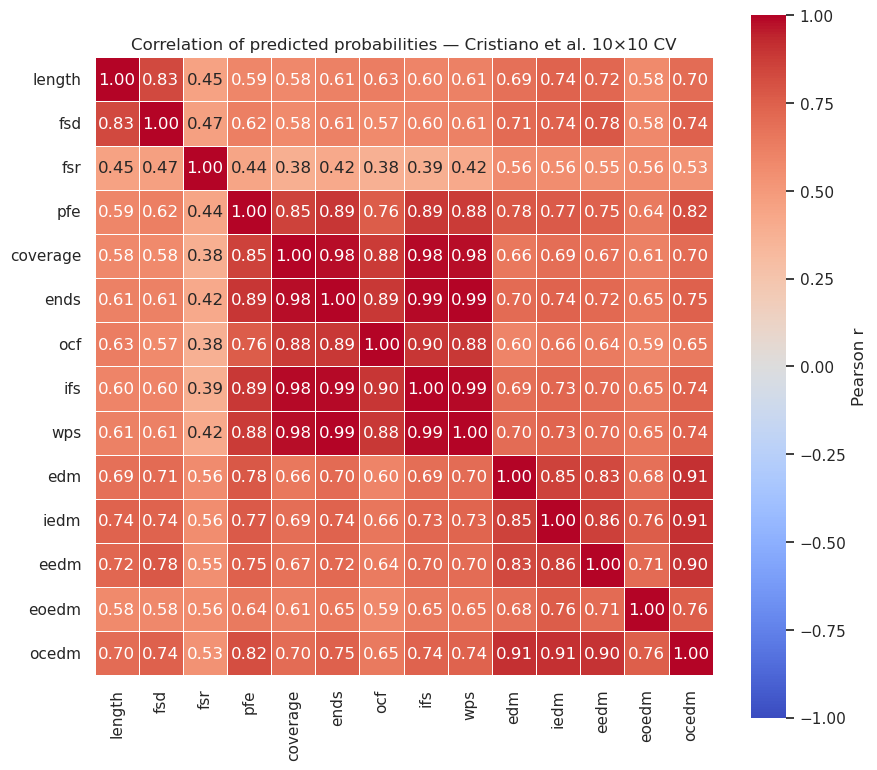

In [166]:
# B5 — Feature correlation heatmap
corr = probs_wide.drop(columns='sample_id').rename(columns=RENAME).corr()
plt.figure(figsize=(9, 8))
sns.set_theme(style="white")
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of predicted probabilities — Cristiano et al. 10×10 CV')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B5_feature_corr.png")
plt.show()


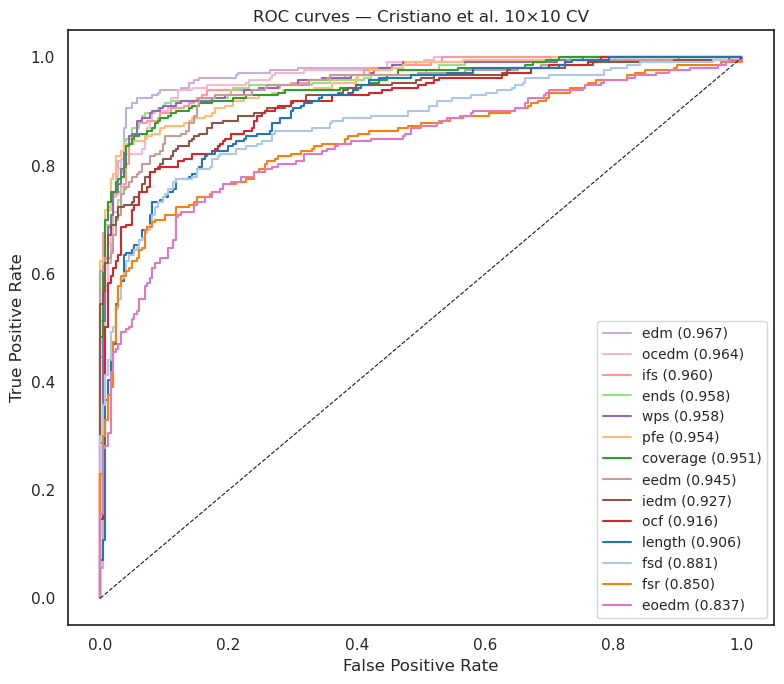

In [167]:
# B6 — ROC curves all features
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — Cristiano et al. 10×10 CV')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B6_roc_cv.png", bbox_inches='tight')
plt.show()


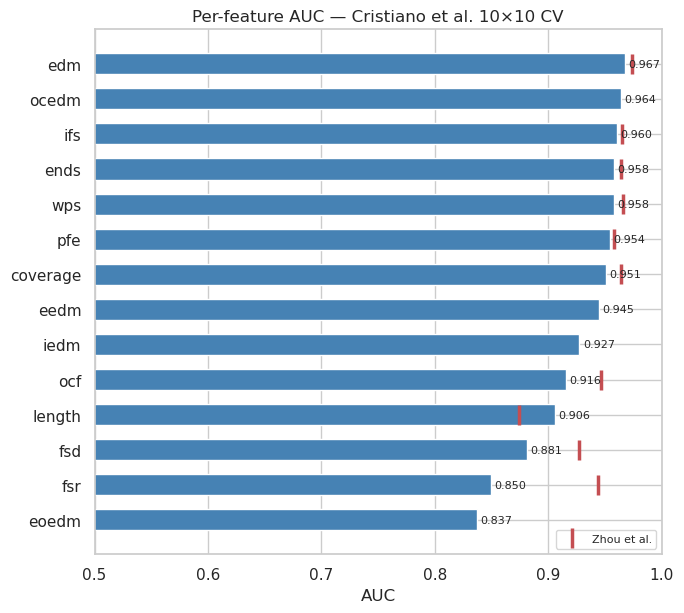

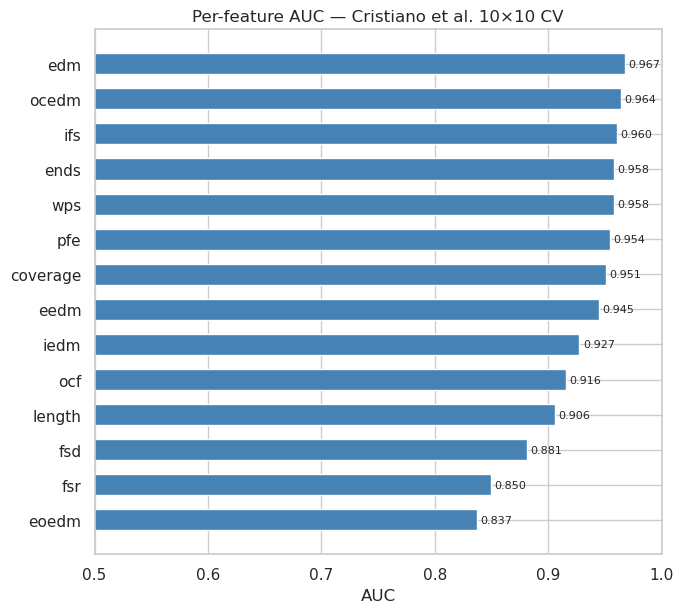

In [168]:
# B7 — AUC bars vs Zhou
fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
sns.set_theme(style='whitegrid')
ax.barh(range(len(names)), aucs, color='steelblue', height=0.6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('Per-feature AUC — Cristiano et al. 10×10 CV')
for i, n in enumerate(names):
    z = ZHOU_SCORES.get(RENAME_INV.get(n, n))
    if z is not None:
        ax.plot(z, i, 'r|', markersize=14, markeredgewidth=2.5,
                label='Zhou et al.' if i == 0 else '')
ax.legend(loc='lower right', fontsize=8)
for i, a in enumerate(aucs):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7_auc_cv.png", bbox_inches='tight')
plt.show()

# B7 no-zhou
fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
ax.barh(range(len(names)), aucs, color='steelblue', height=0.6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('Per-feature AUC — Cristiano et al. 10×10 CV')
for i, a in enumerate(aucs):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7_auc_cv_nozh.png", bbox_inches='tight')
plt.show()


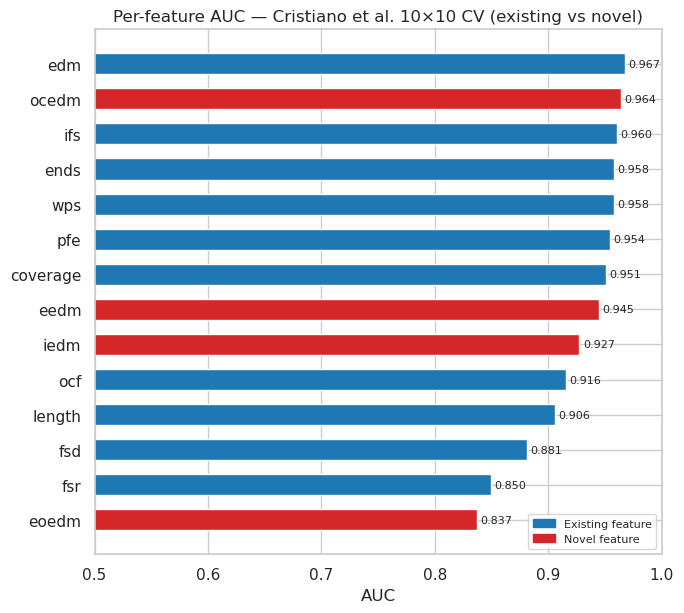

In [169]:
# B7b — AUC bars existing vs novel
fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names)), aucs, color=[_oldnew_color(n) for n in names], height=0.6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('Per-feature AUC — Cristiano et al. 10×10 CV (existing vs novel)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7b_auc_oldnew_cv.png", bbox_inches='tight')
plt.show()


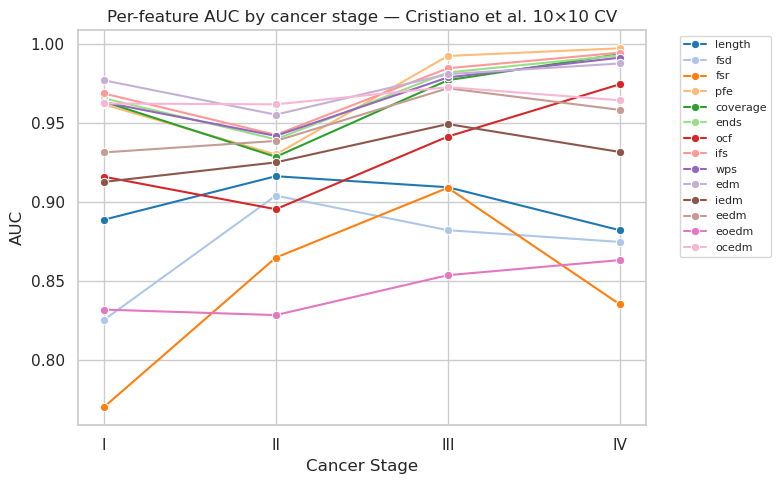

In [170]:
# B9 — Stage-stratified AUC
palette = {RENAME.get(f, f): _fcolor(RENAME.get(f, f)) for f in FEATURE_NAMES}
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.lineplot(data=stage_auc, x='stage', y='auc', hue='feature', marker='o', palette=palette)
plt.xlabel('Cancer Stage'); plt.ylabel('AUC')
plt.title('Per-feature AUC by cancer stage — Cristiano et al. 10×10 CV')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B9_stage_auc_cv.png", bbox_inches='tight')
plt.show()


## C — Cristiano ensemble

In [171]:
ens_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/cv/"
ens_df  = pd.read_csv(ens_dir + "cv_probs.csv").rename(columns={'Unnamed: 0': 'sample_id'})

ens_fpr, ens_tpr, _ = roc_curve(ens_df['label'], ens_df['probability'])
ens_auc  = roc_auc_score(ens_df['label'], ens_df['probability'])
ens_merge = ens_df[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')

cancer_types = (ens_merge[ens_merge['label'] == 1]['disease']
                .value_counts().loc[lambda s: s >= 5].index.tolist())
healthy  = ens_merge[ens_merge['disease'] == 'Healthy']
panels   = ['All cancers'] + cancer_types
type_aucs = {ct: roc_auc_score(
                pd.concat([ens_merge[ens_merge['disease'] == ct], healthy])['label'],
                pd.concat([ens_merge[ens_merge['disease'] == ct], healthy])['probability'])
             for ct in cancer_types}
type_ns = {ct: len(ens_merge[ens_merge['disease'] == ct]) for ct in cancer_types}
print(f"Ensemble AUC: {ens_auc:.4f}  (n={len(ens_df)})")


Ensemble AUC: 0.9918  (n=459)


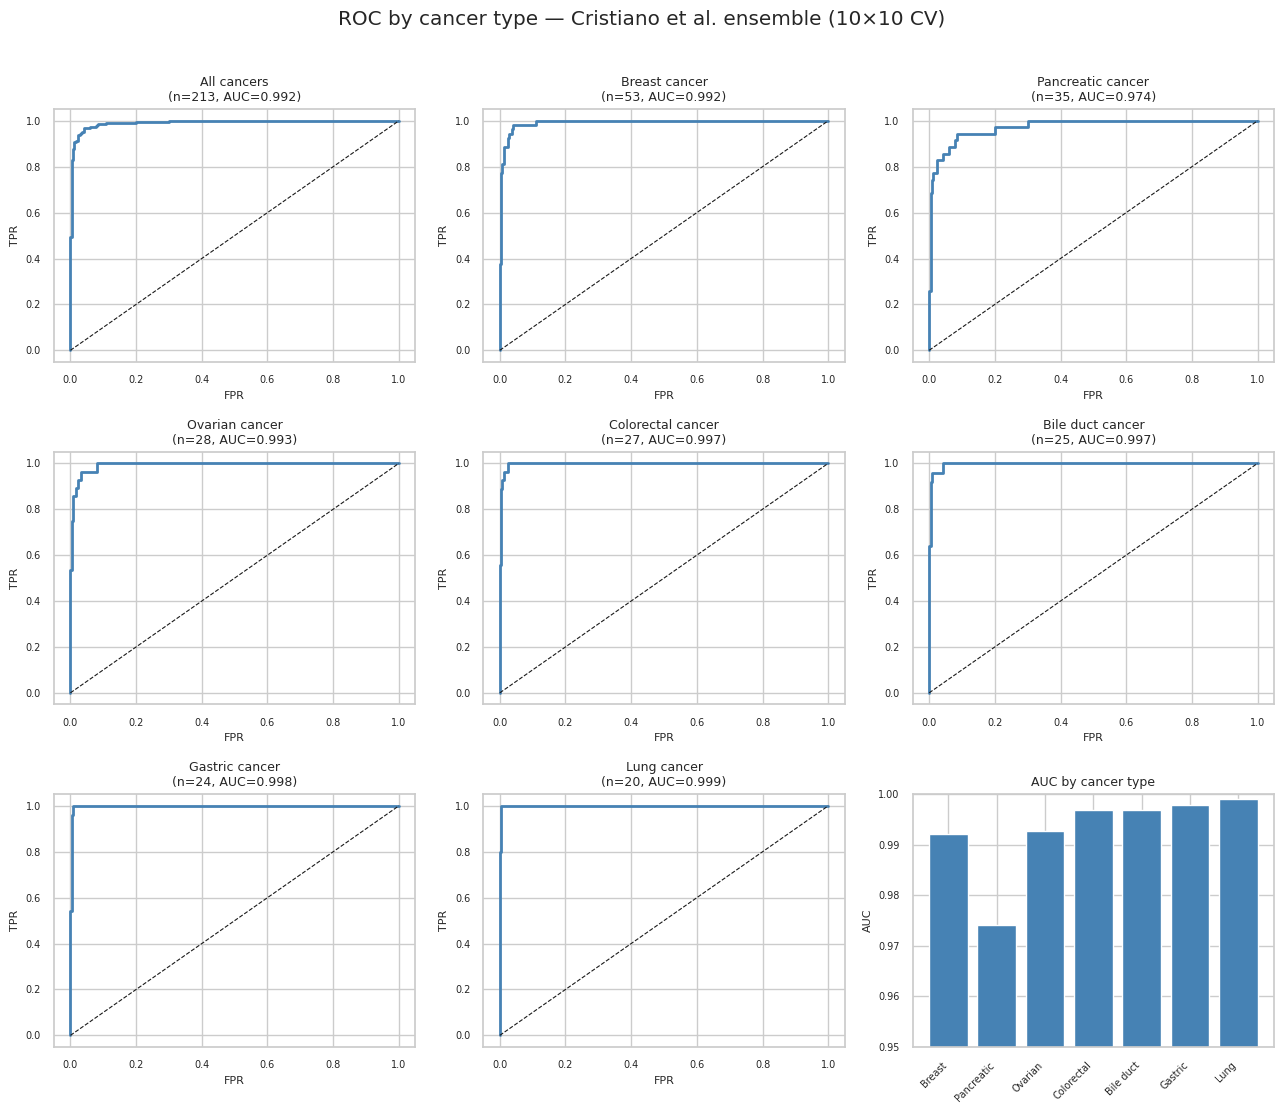

In [172]:
# C12 — ROC by cancer type, 3×3 grid
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
sns.set_theme(style="whitegrid")
for i, ax in enumerate(axes.flatten()):
    if i < len(panels):
        cancer = ens_merge[ens_merge['label'] == 1] if panels[i] == 'All cancers' else ens_merge[ens_merge['disease'] == panels[i]]
        subset = pd.concat([cancer, healthy])
        fpr_t, tpr_t, _ = roc_curve(subset['label'], subset['probability'])
        auc_t = roc_auc_score(subset['label'], subset['probability'])
        ax.plot(fpr_t, tpr_t, color='steelblue', lw=2)
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_title(f"{panels[i]}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
        ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
        ax.tick_params(labelsize=7)
    else:
        short = [ct.replace(' cancer', '') for ct in cancer_types]
        auc_vals = [type_aucs[ct] for ct in cancer_types]
        ax.bar(range(len(cancer_types)), auc_vals, color='steelblue')
        ax.set_xticks(range(len(cancer_types)))
        ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0.95, 1.0); ax.set_ylabel('AUC', fontsize=8)
        ax.set_title('AUC by cancer type', fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle('ROC by cancer type — Cristiano et al. ensemble (10×10 CV)', y=1.01)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C12_roc_cancer_type_grid.png", bbox_inches='tight')
plt.show()


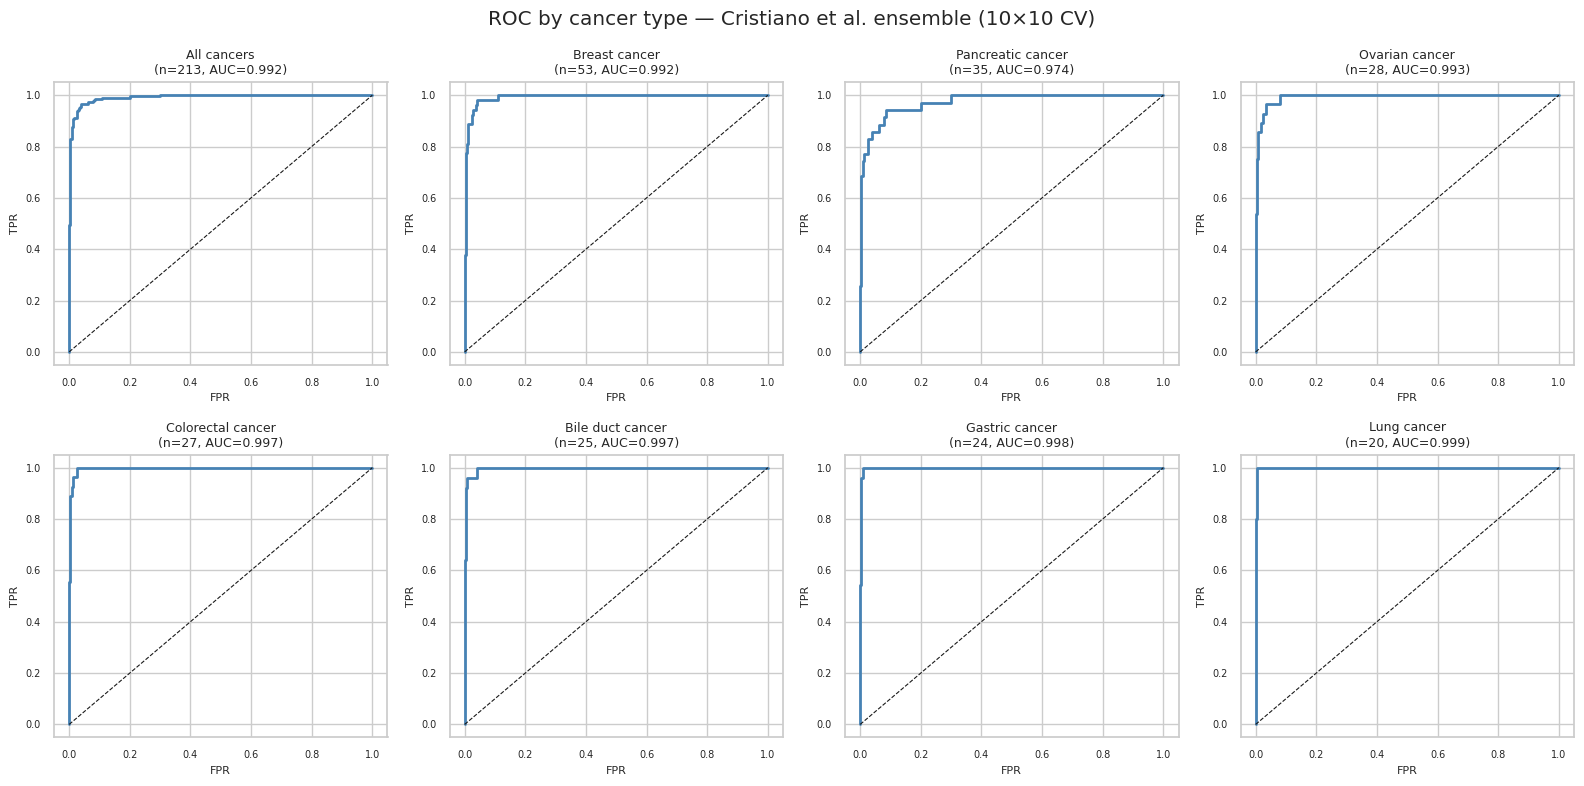

In [173]:
# 2×4 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sns.set_theme(style="whitegrid")
for ax, panel in zip(axes.flatten(), panels):
    if panel == 'All cancers':
        cancer = ens_merge[ens_merge['label'] == 1]
    else:
        cancer = ens_merge[ens_merge['disease'] == panel]
    subset = pd.concat([cancer, healthy])
    fpr_t, tpr_t, _ = roc_curve(subset['label'], subset['probability'])
    auc_t = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_t, tpr_t, color='steelblue', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{panel}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('ROC by cancer type — Cristiano et al. ensemble (10×10 CV)')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C12b_roc_cancer_type_2x4.png", bbox_inches='tight')
plt.show()

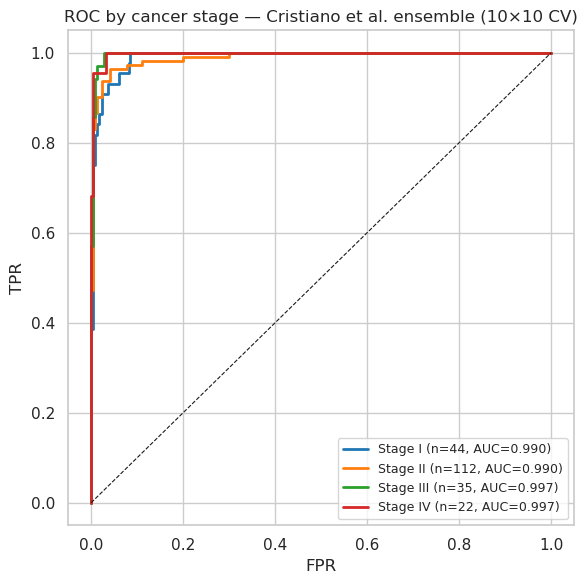

In [174]:
stage_colors = {'I': '#1f77b4', 'II': '#ff7f0e', 'III': '#2ca02c', 'IV': '#d62728'}
healthy_ens  = ens_merge[ens_merge['disease'] == 'Healthy']

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
for stage in ['I', 'II', 'III', 'IV']:
    cancer = ens_merge[(ens_merge['label'] == 1) & (ens_merge['stage'] == stage)]
    if len(cancer) == 0:
        continue
    subset = pd.concat([cancer, healthy_ens])
    fpr_s, tpr_s, _ = roc_curve(subset['label'], subset['probability'])
    auc_s = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_s, tpr_s, color=stage_colors[stage], lw=2,
            label=f"Stage {stage} (n={len(cancer)}, AUC={auc_s:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC by cancer stage — Cristiano et al. ensemble (10×10 CV)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C13_roc_stage_ensemble.png", bbox_inches='tight')
plt.show()

## C (nofsr ensemble) — Cristiano nofsr ensemble (13-feature, no fsr)

In [175]:
nofsr_ens_base = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd_nofsr/"

nofsr_cv_df = pd.read_csv(nofsr_ens_base + "cv/cv_probs.csv").rename(columns={'Unnamed: 0': 'sample_id'})
nofsr_cv_fpr, nofsr_cv_tpr, _ = roc_curve(nofsr_cv_df['label'], nofsr_cv_df['probability'])
nofsr_cv_auc = roc_auc_score(nofsr_cv_df['label'], nofsr_cv_df['probability'])
nofsr_cv_merge = nofsr_cv_df.merge(manifest, on='sample_id', how='left')

nofsr_cv_roc_feats = [d for d in cv_roc if d['name'] != 'fsr']
names_nofsr_cv = [d['name'] for d in nofsr_cv_roc_feats]
aucs_nofsr_cv  = [d['auc']  for d in nofsr_cv_roc_feats]

nofsr_healthy      = nofsr_cv_merge[nofsr_cv_merge['disease'] == 'Healthy']
nofsr_cancer_types = (nofsr_cv_merge[nofsr_cv_merge['label'] == 1]['disease']
                      .value_counts().loc[lambda s: s >= 5].index.tolist())
nofsr_panels = ['All cancers'] + nofsr_cancer_types
print(f"nofsr ensemble CV AUC: {nofsr_cv_auc:.4f}  (n={len(nofsr_cv_df)})")


nofsr ensemble CV AUC: 0.9918  (n=459)


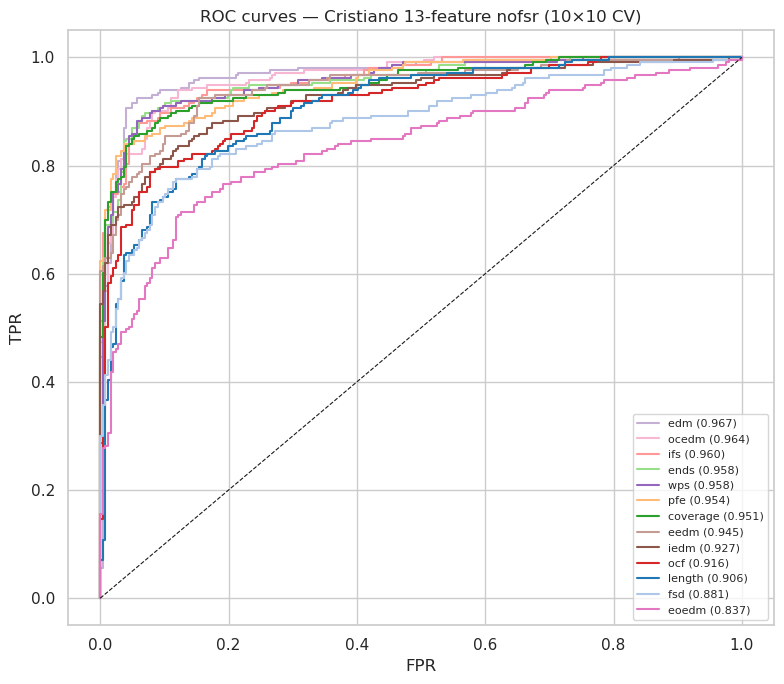

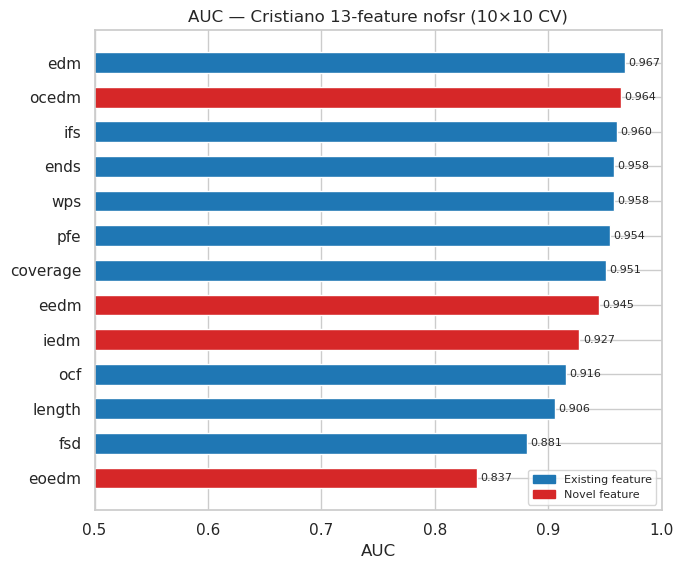

In [176]:
# C nofsr — per-feature ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in nofsr_cv_roc_feats:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC curves — Cristiano 13-feature nofsr (10×10 CV)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_roc_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_nofsr_cv) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_nofsr_cv)), aucs_nofsr_cv,
        color=[_oldnew_color(n) for n in names_nofsr_cv], height=0.6)
ax.set_yticks(range(len(names_nofsr_cv))); ax.set_yticklabels(names_nofsr_cv)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — Cristiano 13-feature nofsr (10×10 CV)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_nofsr_cv):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_auc_cv.png", bbox_inches='tight')
plt.show()


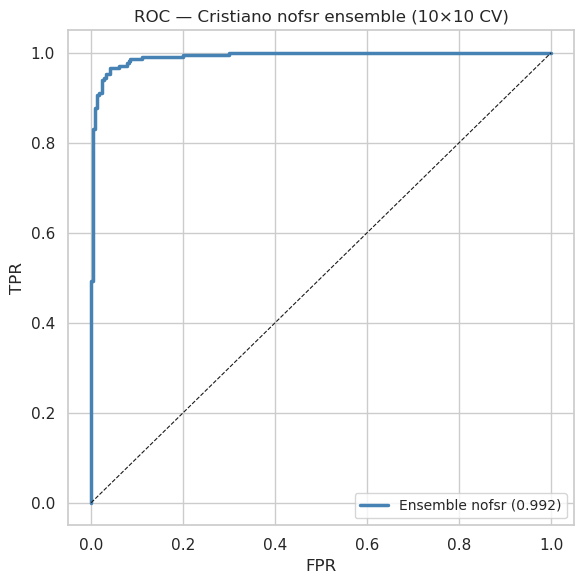

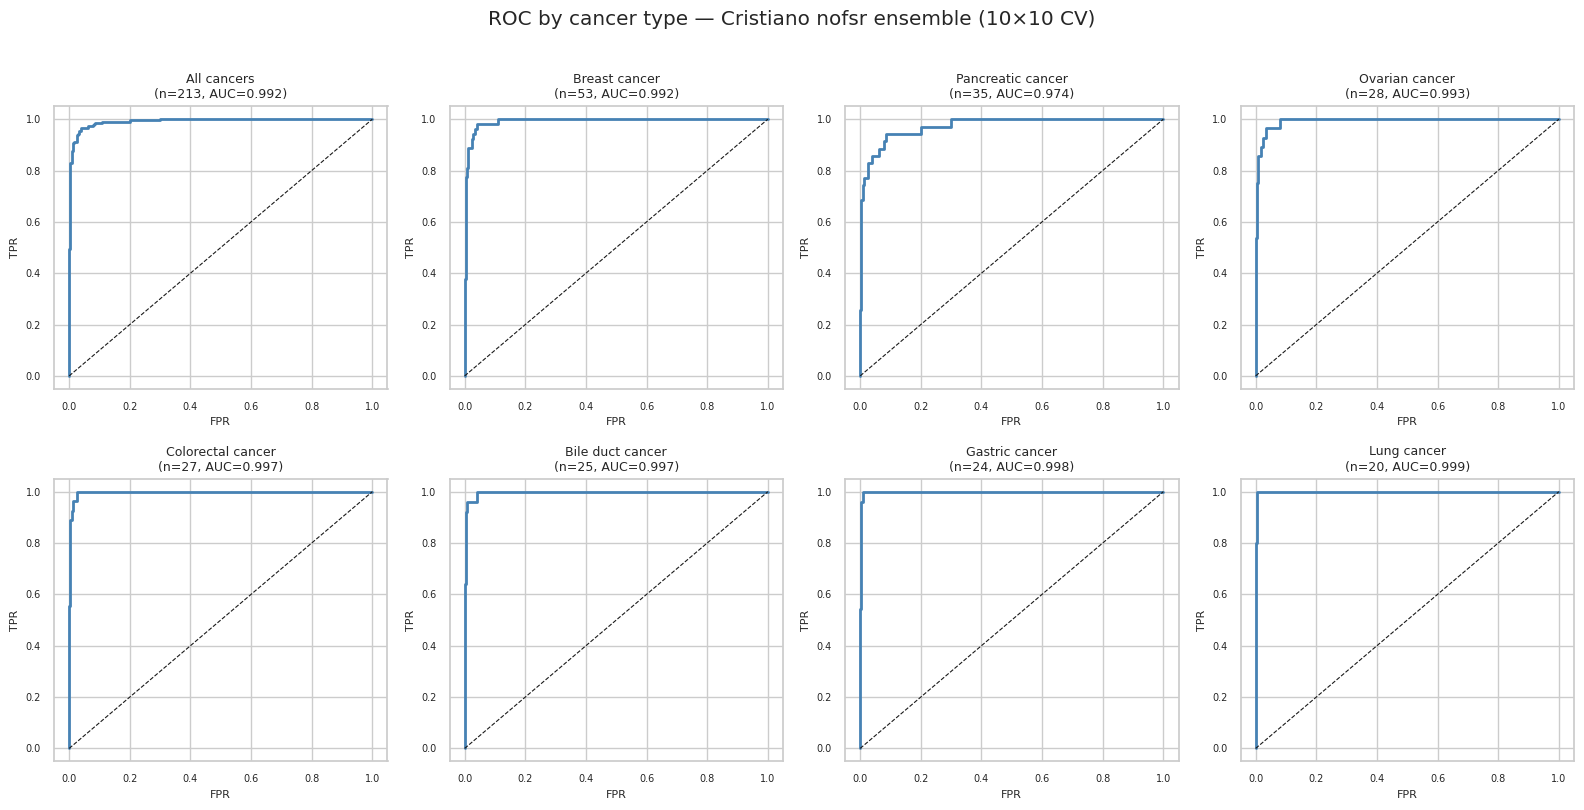

In [177]:
# Ensemble single ROC
fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
ax.plot(nofsr_cv_fpr, nofsr_cv_tpr, color='steelblue', linewidth=2.5,
        label=f"Ensemble nofsr ({nofsr_cv_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr ensemble (10×10 CV)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_ens_roc_cv.png", bbox_inches='tight')
plt.show()

# Cancer type 2×4 grid
nofsr_healthy = nofsr_cv_merge[nofsr_cv_merge['disease'] == 'Healthy']
nofsr_cancer_types = (nofsr_cv_merge[nofsr_cv_merge['label'] == 1]['disease']
                      .value_counts()
                      .loc[lambda s: s >= 5].index.tolist())
nofsr_panels = ['All cancers'] + nofsr_cancer_types

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sns.set_theme(style="whitegrid")
for ax, panel in zip(axes.flatten(), nofsr_panels):
    cancer = (nofsr_cv_merge[nofsr_cv_merge['label'] == 1] if panel == 'All cancers'
              else nofsr_cv_merge[nofsr_cv_merge['disease'] == panel])
    subset = pd.concat([cancer, nofsr_healthy])
    fpr_t, tpr_t, _ = roc_curve(subset['label'], subset['probability'])
    auc_t = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_t, tpr_t, color='steelblue', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{panel}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.flatten()[len(nofsr_panels):]:
    ax.set_visible(False)
plt.suptitle('ROC by cancer type — Cristiano nofsr ensemble (10×10 CV)', y=1.01)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_ens_cancer_type_cv.png", bbox_inches='tight')
plt.show()


## D — External validation (Cristiano-trained)

In [178]:
ly_test_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
gs_test_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"

ly_roc = load_roc_data(ly_test_dir)
gs_roc = load_roc_data(gs_test_dir)

names_ly = [d['name'] for d in ly_roc]; aucs_ly = [d['auc'] for d in ly_roc]
names_gs = [d['name'] for d in gs_roc]; aucs_gs = [d['auc'] for d in gs_roc]


Missing: ['fsr']
Missing: ['fsr']


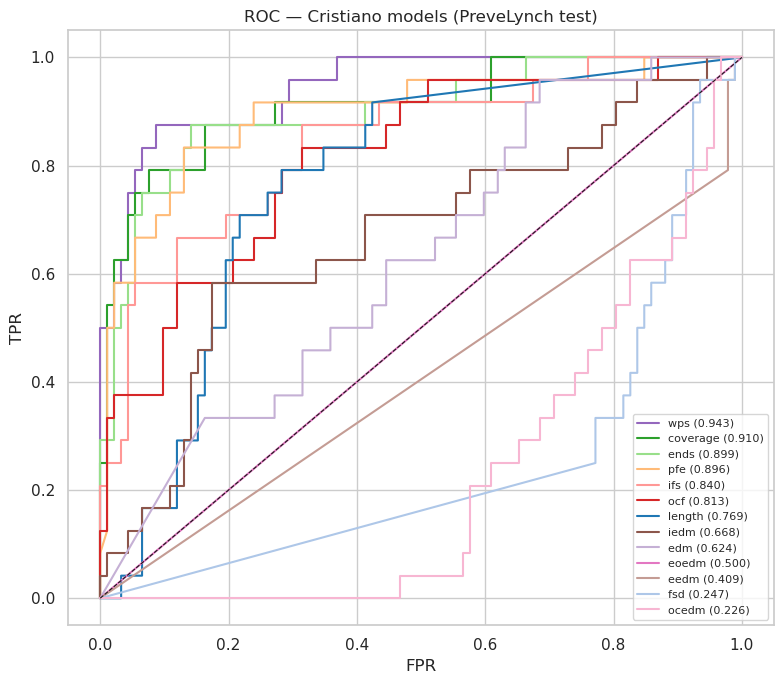

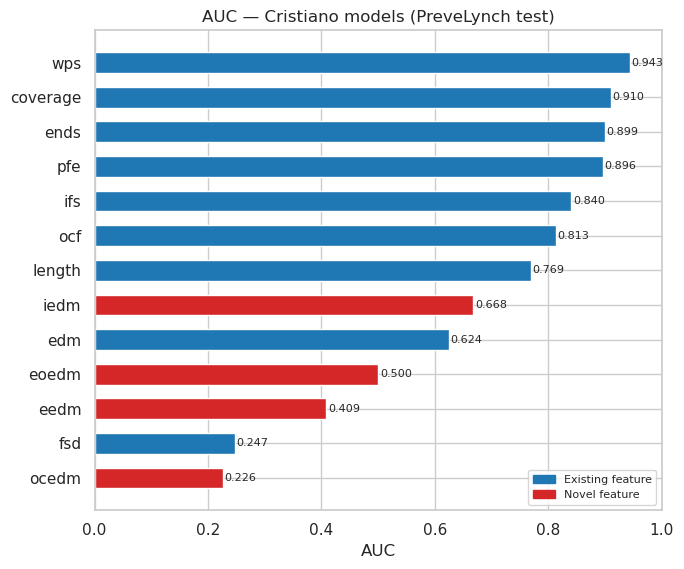

In [179]:
# D14 — Cristiano → PreveLynch ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D14_roc_crist_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_ly) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_ly)), aucs_ly, color=[_oldnew_color(n) for n in names_ly], height=0.6)
ax.set_yticks(range(len(names_ly))); ax.set_yticklabels(names_ly)
ax.invert_yaxis(); ax.set_xlim(0, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — Cristiano models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_ly):
    ax.text(max(a + 0.003, 0.003), i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D14b_auc_crist_ly.png", bbox_inches='tight')
plt.show()


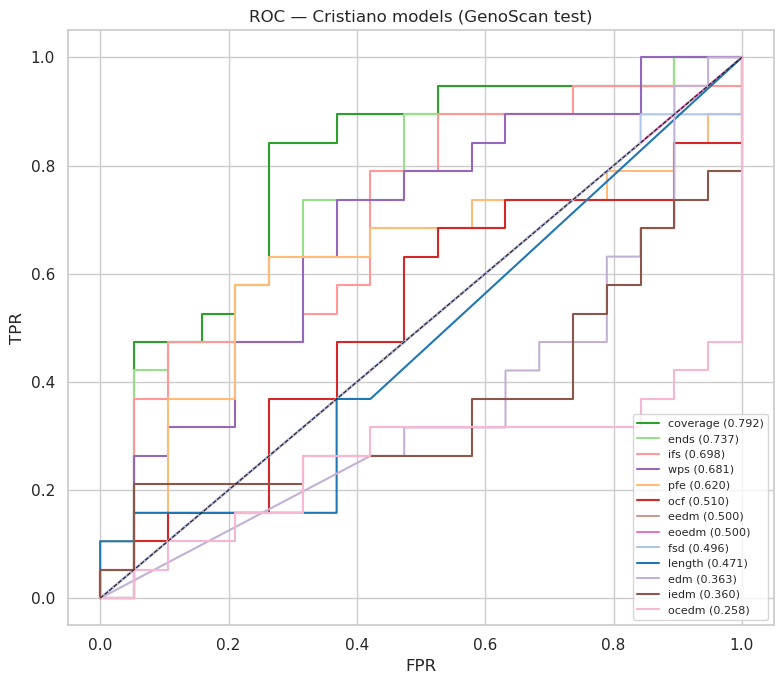

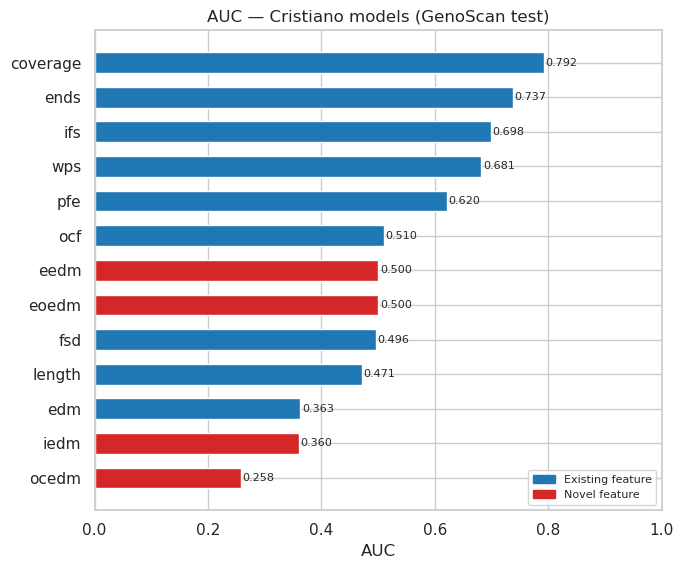

In [180]:
# D15 — Cristiano → GenoScan ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano models (GenoScan test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D15_roc_crist_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_gs) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_gs)), aucs_gs, color=[_oldnew_color(n) for n in names_gs], height=0.6)
ax.set_yticks(range(len(names_gs))); ax.set_yticklabels(names_gs)
ax.invert_yaxis(); ax.set_xlim(0, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — Cristiano models (GenoScan test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_gs):
    ax.text(max(a + 0.003, 0.003), i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D15b_auc_crist_gs.png", bbox_inches='tight')
plt.show()


## D (nofsr ensemble) — Cristiano nofsr ensemble external test

In [181]:
_nofsr_test_base = nofsr_ens_base + "test/ensemble_nostd_nofsr/test/"

nofsr_ly_df = pd.read_csv(_nofsr_test_base + "prevelynch_test_preds.csv")
nofsr_ly_fpr, nofsr_ly_tpr, _ = roc_curve(nofsr_ly_df['label'], nofsr_ly_df['probability'])
nofsr_ly_auc = roc_auc_score(nofsr_ly_df['label'], nofsr_ly_df['probability'])

nofsr_gs_df = pd.read_csv(_nofsr_test_base + "genoscan_preds.csv")
nofsr_gs_fpr, nofsr_gs_tpr, _ = roc_curve(nofsr_gs_df['label'], nofsr_gs_df['probability'])
nofsr_gs_auc = roc_auc_score(nofsr_gs_df['label'], nofsr_gs_df['probability'])

print(f"nofsr ensemble → LY AUC: {nofsr_ly_auc:.4f}  (n={len(nofsr_ly_df)})")
print(f"nofsr ensemble → GS AUC: {nofsr_gs_auc:.4f}  (n={len(nofsr_gs_df)})")


nofsr ensemble → LY AUC: 0.8886  (n=116)
nofsr ensemble → GS AUC: 0.5097  (n=38)


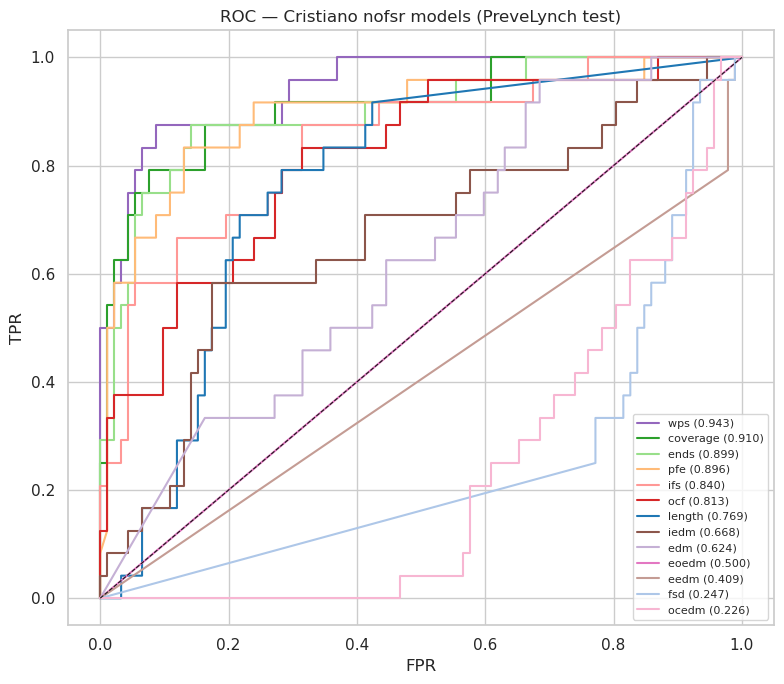

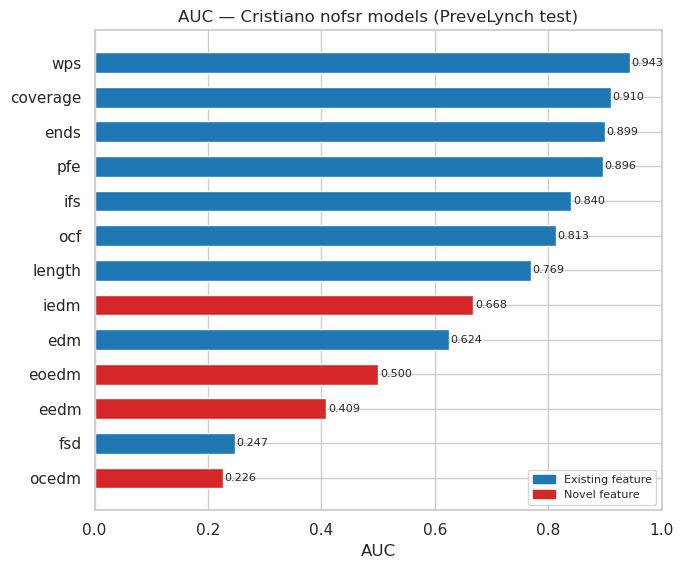

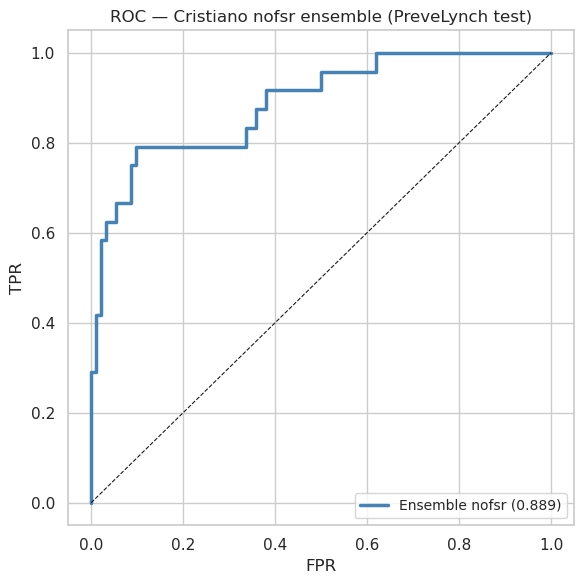

In [182]:
# D nofsr — PreveLynch: per-feature ROC + nofsr ensemble ROC
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_roc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_ly) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_ly)), aucs_ly, color=[_oldnew_color(n) for n in names_ly], height=0.6)
ax.set_yticks(range(len(names_ly))); ax.set_yticklabels(names_ly)
ax.invert_yaxis(); ax.set_xlim(0, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — Cristiano nofsr models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_ly):
    ax.text(max(a + 0.003, 0.003), i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_auc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
ax.plot(nofsr_ly_fpr, nofsr_ly_tpr, color='steelblue', linewidth=2.5,
        label=f"Ensemble nofsr ({nofsr_ly_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr ensemble (PreveLynch test)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_ens_roc_ly.png", bbox_inches='tight')
plt.show()


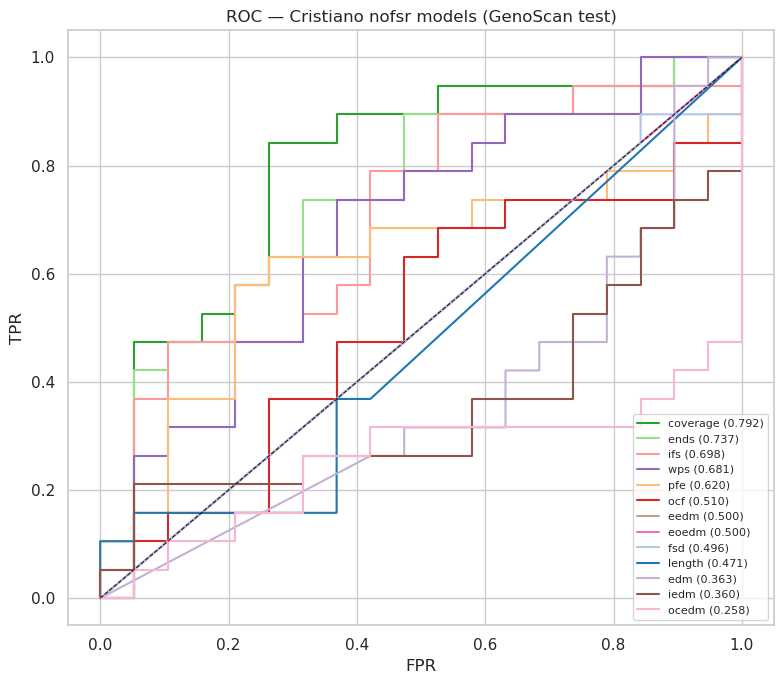

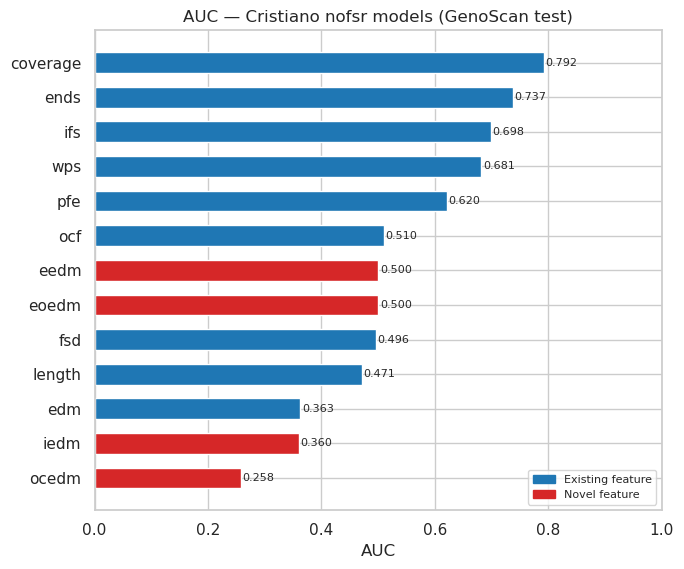

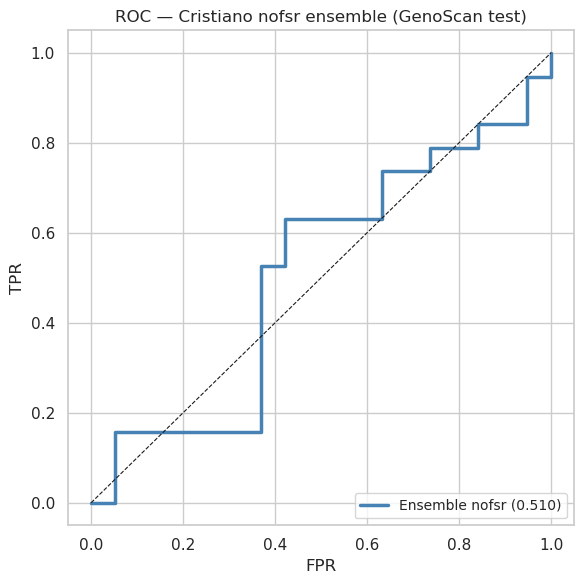

In [183]:
# D nofsr — GenoScan: per-feature ROC + nofsr ensemble ROC
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr models (GenoScan test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_roc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_gs) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_gs)), aucs_gs, color=[_oldnew_color(n) for n in names_gs], height=0.6)
ax.set_yticks(range(len(names_gs))); ax.set_yticklabels(names_gs)
ax.invert_yaxis(); ax.set_xlim(0, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — Cristiano nofsr models (GenoScan test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_gs):
    ax.text(max(a + 0.003, 0.003), i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_auc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
ax.plot(nofsr_gs_fpr, nofsr_gs_tpr, color='steelblue', linewidth=2.5,
        label=f"Ensemble nofsr ({nofsr_gs_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr ensemble (GenoScan test)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_ens_roc_gs.png", bbox_inches='tight')
plt.show()


## D (LY-trained) — LY CV and external test
Note: LY cohort contains only CRC + controls — no cancer-type grid.

In [184]:
ly_cv_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
ly_ly_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"

ly_cv_roc = load_roc_data(ly_cv_dir, suffix='_cv_probs.csv')
ly_ly_roc = load_roc_data(ly_ly_dir)

names_ly_cv = [d['name'] for d in ly_cv_roc]; aucs_ly_cv = [d['auc'] for d in ly_cv_roc]
names_ly_ly = [d['name'] for d in ly_ly_roc]; aucs_ly_ly = [d['auc'] for d in ly_ly_roc]


Missing: ['pfe', 'coverage', 'ends', 'ocf', 'wps']
Missing: ['fsr']


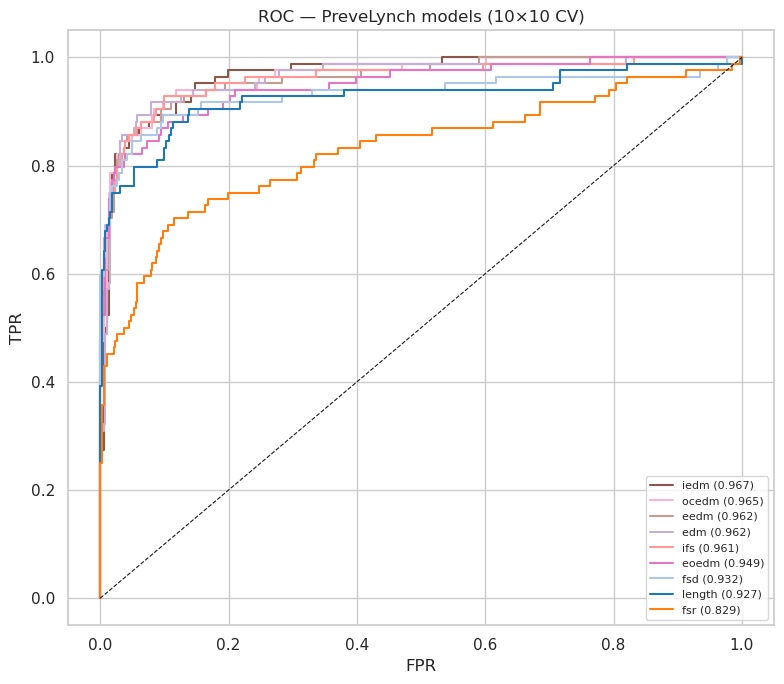

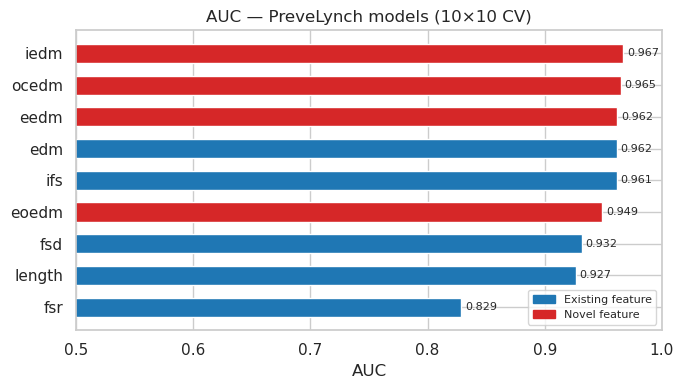

In [185]:
# D19 — PreveLynch CV ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch models (10×10 CV)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D19_roc_ly_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_ly_cv) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_ly_cv)), aucs_ly_cv,
        color=[_oldnew_color(n) for n in names_ly_cv], height=0.6)
ax.set_yticks(range(len(names_ly_cv))); ax.set_yticklabels(names_ly_cv)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — PreveLynch models (10×10 CV)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_ly_cv):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D19b_auc_ly_cv.png", bbox_inches='tight')
plt.show()


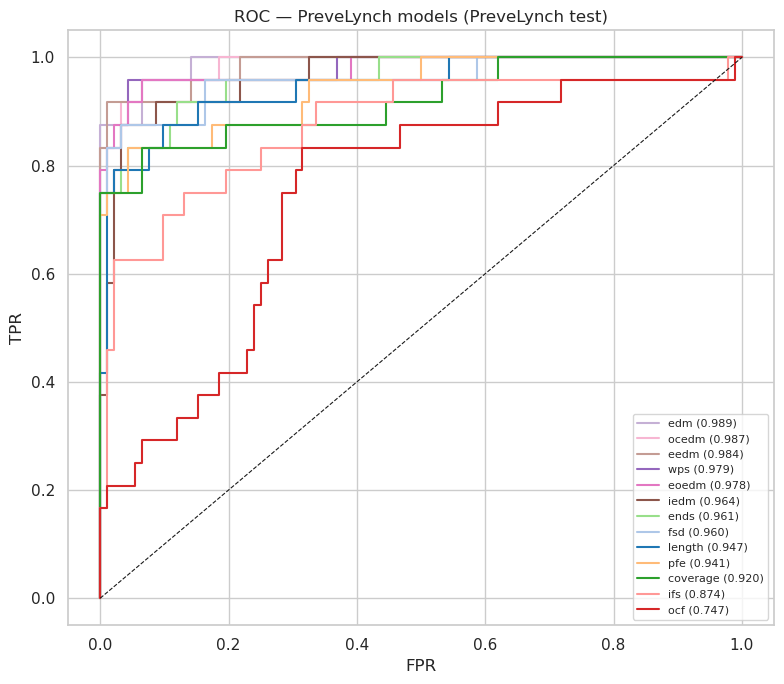

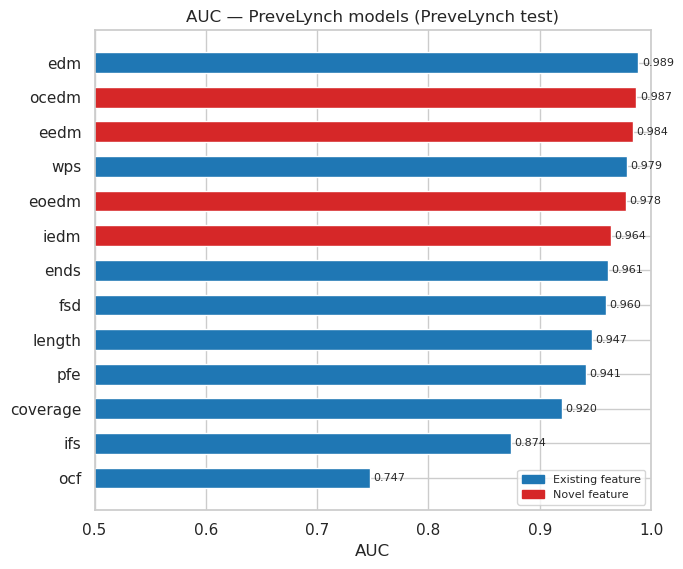

In [186]:
# D20 — PreveLynch models → PreveLynch test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20_roc_ly_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_ly_ly) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_ly_ly)), aucs_ly_ly,
        color=[_oldnew_color(n) for n in names_ly_ly], height=0.6)
ax.set_yticks(range(len(names_ly_ly))); ax.set_yticklabels(names_ly_ly)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — PreveLynch models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_ly_ly):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20b_auc_ly_ly.png", bbox_inches='tight')
plt.show()


## D (CRC-trained) — CRC CV and external test
Note: CRC cohort contains only Colorectal cancer + controls.

In [187]:
crc_cv_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
crc_ly_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
crc_gs_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"
crc_manifest = pd.read_csv("data/manifest/Cristiano_metadata_crc.csv")[['sample_id', 'disease', 'stage']]

crc_cv_roc = load_roc_data(crc_cv_dir, suffix='_cv_probs.csv')
crc_ly_roc = load_roc_data(crc_ly_dir)
crc_gs_roc = load_roc_data(crc_gs_dir)

names_crc_cv = [d['name'] for d in crc_cv_roc]; aucs_crc_cv = [d['auc'] for d in crc_cv_roc]
names_crc_ly = [d['name'] for d in crc_ly_roc]; aucs_crc_ly = [d['auc'] for d in crc_ly_roc]
names_crc_gs = [d['name'] for d in crc_gs_roc]; aucs_crc_gs = [d['auc'] for d in crc_gs_roc]


Missing: ['fsr', 'pfe', 'coverage', 'wps']
Missing: ['fsr']
Missing: ['fsr']


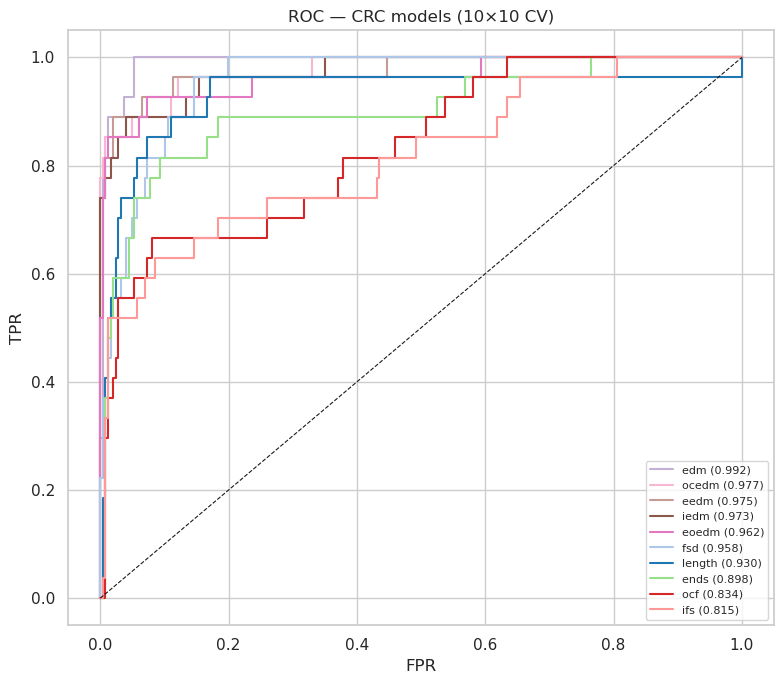

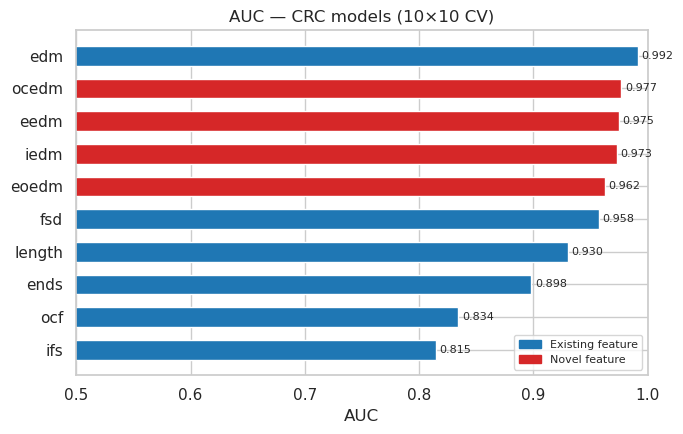

In [188]:
# D16 — CRC CV ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in crc_cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (10×10 CV)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D16_roc_crc_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_crc_cv) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_crc_cv)), aucs_crc_cv,
        color=[_oldnew_color(n) for n in names_crc_cv], height=0.6)
ax.set_yticks(range(len(names_crc_cv))); ax.set_yticklabels(names_crc_cv)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — CRC models (10×10 CV)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_crc_cv):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D16b_auc_crc_cv.png", bbox_inches='tight')
plt.show()


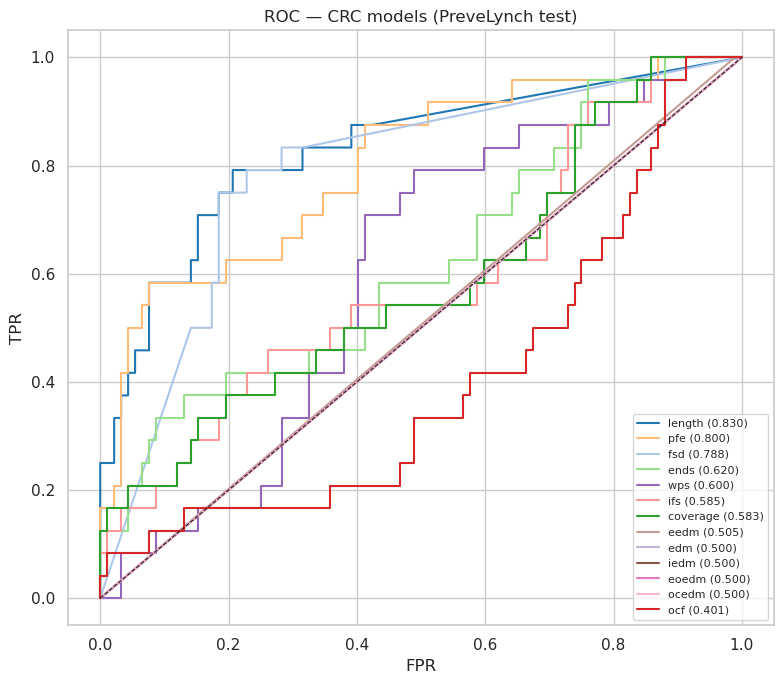

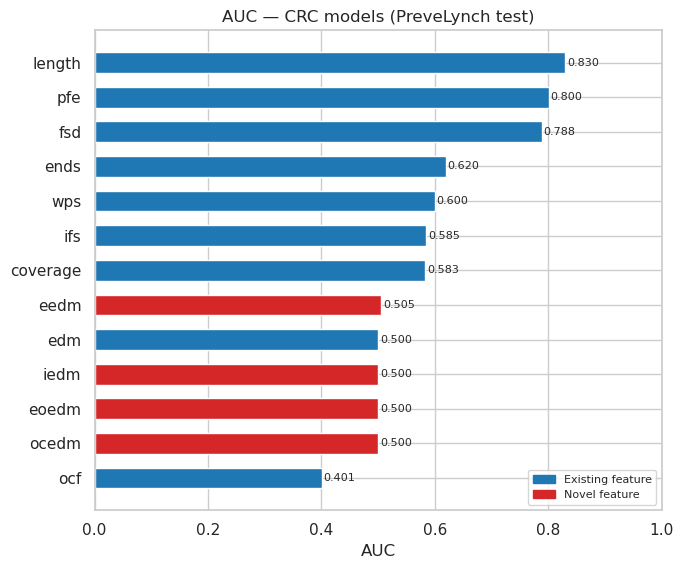

In [189]:
# D17 — CRC models → PreveLynch ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in crc_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D17_roc_crc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_crc_ly) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_crc_ly)), aucs_crc_ly,
        color=[_oldnew_color(n) for n in names_crc_ly], height=0.6)
ax.set_yticks(range(len(names_crc_ly))); ax.set_yticklabels(names_crc_ly)
ax.invert_yaxis(); ax.set_xlim(0, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — CRC models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_crc_ly):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D17b_auc_crc_ly.png", bbox_inches='tight')
plt.show()


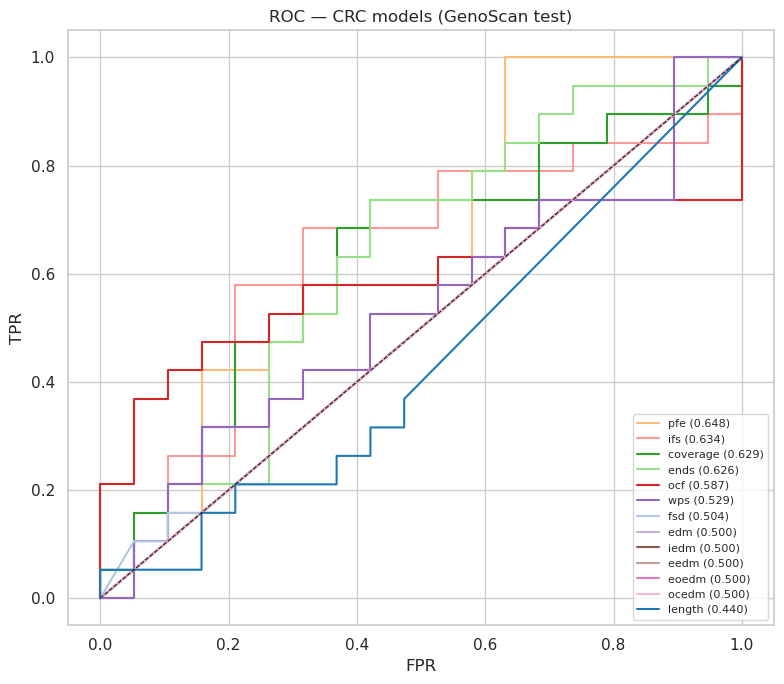

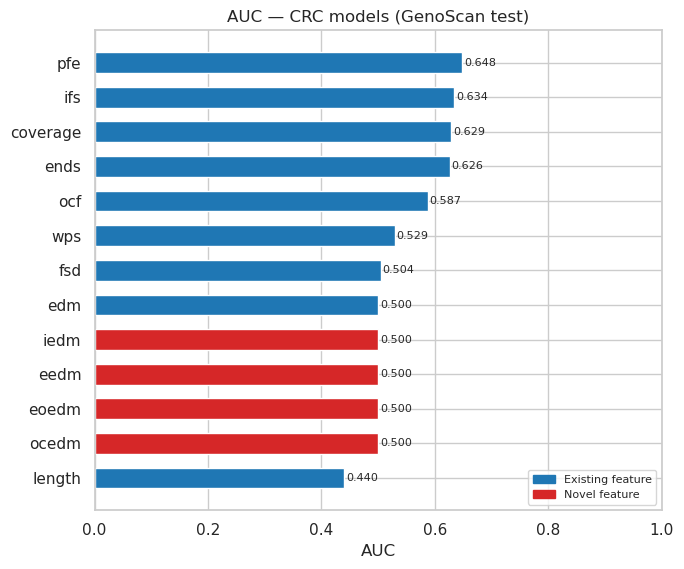

In [190]:
# D18 — CRC models → GenoScan ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in crc_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (GenoScan test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D18_roc_crc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, max(4, len(names_crc_gs) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names_crc_gs)), aucs_crc_gs,
        color=[_oldnew_color(n) for n in names_crc_gs], height=0.6)
ax.set_yticks(range(len(names_crc_gs))); ax.set_yticklabels(names_crc_gs)
ax.invert_yaxis(); ax.set_xlim(0, 1.0); ax.set_xlabel('AUC')
ax.set_title('AUC — CRC models (GenoScan test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs_crc_gs):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D18b_auc_crc_gs.png", bbox_inches='tight')
plt.show()
